# 03 — Ito Lemma and the Black-Scholes PDE

## Purpose

This notebook connects the two foundations already built:

| Previous notebook | Role |
|---|---|
| `01_binomial_no_arbitrage_replication.ipynb` | Pricing comes from replication and no-arbitrage, not forecasting. |
| `02_brownian_motion_gbm_and_quadratic_variation.ipynb` | Brownian motion has quadratic variation, so ordinary calculus is not enough. |

The goal here is to derive the **Black-Scholes PDE** from three ingredients:

1. geometric Brownian motion,
2. Ito's lemma,
3. delta hedging plus no-arbitrage.

This notebook derives the PDE.  
The closed-form Black-Scholes formula and full Greek checks are handled in the next notebook.

---

## Central question

Assume the stock follows geometric Brownian motion:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

Let a European derivative have value

$$
V = V(S,t).
$$

The question is:

> What condition must \(V(S,t)\) satisfy so that the derivative price is consistent with no-arbitrage?

---

## Core idea

Ito's lemma gives the movement of the derivative value:

$$
dV
=
\left(
V_t
+
\mu S V_S
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
\right)dt
+
\sigma S V_S\,dW_t.
$$

The derivative inherits randomness from the stock through the term

$$
\sigma S V_S\,dW_t.
$$

A delta hedge chooses the stock position so that this Brownian risk cancels.  
Once the random term is removed, the hedged portfolio is locally riskless.  
By no-arbitrage, a locally riskless portfolio must earn the risk-free rate.

That logic forces the derivative value to satisfy:

$$
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
+
rS V_S
-
rV
=
0.
$$

This is the **Black-Scholes partial differential equation**.

---

## Why this matters

The important result is not just the PDE itself.

The important result is that the real-world drift \(\mu\) disappears.

The stock dynamics contain \(\mu\):

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t,
$$

but the pricing PDE does not:

$$
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
+
rS V_S
-
rV
=
0.
$$

The drift is not ignored.  
It is cancelled by the hedge.

This is the continuous-time version of the lesson from the binomial notebook:

> derivative pricing is about replication and no-arbitrage, not predicting the expected return of the underlying.

---

## Notebook roadmap

1. Set up the GBM stock model and risk-free account.
2. Explain why ordinary calculus fails for Brownian-driven processes.
3. State Ito's lemma for \(V(S,t)\).
4. Apply Ito's lemma to \(\log S_t\) as a warm-up.
5. Apply Ito's lemma to the derivative value \(V(S,t)\).
6. Build the delta-hedged portfolio.
7. Show that the \(dW_t\) term cancels.
8. Derive the Black-Scholes PDE.
9. Explain why \(\mu\) disappears.
10. Verify numerically that the Black-Scholes call price satisfies the PDE.

---

## What this notebook proves

By the end of this notebook, the following claims should be justified:

| Claim | Meaning |
|---|---|
| Ito's lemma adds a second-derivative term | Brownian quadratic variation makes curvature matter. |
| Delta is the hedge ratio | The stock position is chosen to cancel the derivative's Brownian exposure. |
| The hedged portfolio is locally riskless | After cancellation, there is no \(dW_t\) term. |
| The hedged portfolio must earn \(r\) | Otherwise there is arbitrage. |
| The option price satisfies the Black-Scholes PDE | No-arbitrage imposes a differential equation on \(V(S,t)\). |
| \(\mu\) disappears | Expected stock return is hedged away, not forecasted. |

---

## What this notebook does not prove

This notebook does not claim that:

| Not proved here | Reason |
|---|---|
| GBM is realistic | Real markets have jumps, stochastic volatility, frictions, and discrete trading. |
| The Black-Scholes formula has been derived | The PDE is derived here; the formula is handled next. |
| Hedging is perfect in practice | Continuous trading is an idealization. |
| Volatility is constant in real option markets | Smile and surface effects are handled later. |
| Heston or Bates is justified | Those models require additional theory beyond this notebook. |

---

## Handoff

This notebook produces the PDE foundation.

The next notebook uses that foundation to study the closed-form Black-Scholes price and Greeks:

**`04_black_scholes_formula_greeks_and_numerical_checks.ipynb`**

In [1]:
# Cell 02 — Imports, configuration, and model setup

from __future__ import annotations

from dataclasses import dataclass
from typing import Final

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------------------
# Global notebook configuration
# ---------------------------------------------------------------------

RNG_SEED: Final[int] = 620_03
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.float_format", "{:,.6f}".format)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


# ---------------------------------------------------------------------
# Baseline Black-Scholes-Merton setup
# ---------------------------------------------------------------------

@dataclass(frozen=True)
class BSMSetup:
    """
    Baseline continuous-time model setup for deriving the Black-Scholes PDE.

    S0    : initial stock price
    K     : option strike
    T     : maturity in years
    r     : continuously compounded risk-free rate
    mu    : real-world stock drift
    sigma : stock volatility
    """
    S0: float
    K: float
    T: float
    r: float
    mu: float
    sigma: float

    def validate(self) -> None:
        if self.S0 <= 0:
            raise ValueError("S0 must be positive.")
        if self.K <= 0:
            raise ValueError("K must be positive.")
        if self.T <= 0:
            raise ValueError("T must be positive.")
        if self.sigma <= 0:
            raise ValueError("sigma must be positive.")
        if math.isclose(self.mu, self.r):
            raise ValueError(
                "mu and r are intentionally required to differ in this notebook "
                "so that the disappearance of mu from the PDE is visible."
            )


setup = BSMSetup(
    S0=100.0,
    K=100.0,
    T=1.0,
    r=0.05,
    mu=0.10,
    sigma=0.20,
)

setup.validate()


# ---------------------------------------------------------------------
# Display setup audit
# ---------------------------------------------------------------------

setup_table = pd.DataFrame(
    [
        {
            "symbol": "S0",
            "value": setup.S0,
            "meaning": "Initial stock price",
        },
        {
            "symbol": "K",
            "value": setup.K,
            "meaning": "Option strike",
        },
        {
            "symbol": "T",
            "value": setup.T,
            "meaning": "Time to maturity in years",
        },
        {
            "symbol": "r",
            "value": setup.r,
            "meaning": "Risk-free rate",
        },
        {
            "symbol": "mu",
            "value": setup.mu,
            "meaning": "Real-world stock drift",
        },
        {
            "symbol": "sigma",
            "value": setup.sigma,
            "meaning": "Stock volatility",
        },
    ]
)

setup_audit = pd.DataFrame(
    [
        {
            "check": "Positive initial stock price",
            "requirement": "S0 > 0",
            "status": "PASS" if setup.S0 > 0 else "FAIL",
        },
        {
            "check": "Positive strike",
            "requirement": "K > 0",
            "status": "PASS" if setup.K > 0 else "FAIL",
        },
        {
            "check": "Positive maturity",
            "requirement": "T > 0",
            "status": "PASS" if setup.T > 0 else "FAIL",
        },
        {
            "check": "Positive volatility",
            "requirement": "sigma > 0",
            "status": "PASS" if setup.sigma > 0 else "FAIL",
        },
        {
            "check": "Real-world drift distinct from risk-free rate",
            "requirement": "mu != r",
            "status": "PASS" if not math.isclose(setup.mu, setup.r) else "FAIL",
        },
    ]
)

print("Baseline model setup")
display(setup_table)

print("Setup audit")
display(setup_audit)

NOTEBOOK_03_SETUP_READY = (setup_audit["status"] == "PASS").all()
print(f"NOTEBOOK_03_SETUP_READY: {NOTEBOOK_03_SETUP_READY}")

Baseline model setup


,symbol,value,meaning
0,S0,100.000000,Initial stock price
1,K,100.000000,Option strike
2,T,1.000000,Time to maturity in years
3,r,0.050000,Risk-free rate
4,mu,0.100000,Real-world stock drift
5,sigma,0.200000,Stock volatility


Setup audit


,check,requirement,status
0,Positive initial stock price,S0 > 0,PASS
1,Positive strike,K > 0,PASS
2,Positive maturity,T > 0,PASS
3,Positive volatility,sigma > 0,PASS
4,Real-world drift distinct from risk-free rate,mu != r,PASS


NOTEBOOK_03_SETUP_READY: True


## 1. Continuous-time market setup

The numerical setup above defines the objects used throughout the notebook.

We work with two traded assets:

| Asset | Dynamics | Interpretation |
|---|---|---|
| Stock | $$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$$ | Risky asset driven by Brownian motion |
| Money-market account | $$dB_t = rB_t\,dt$$ | Locally riskless asset growing at rate \(r\) |

The stock has real-world drift \(\mu\), volatility \(\sigma\), and Brownian shock \(dW_t\).

The money-market account has no Brownian shock. It grows deterministically at the risk-free rate.

---

The derivative value is assumed to be a smooth function of the stock price and time:

$$
V = V(S,t).
$$

For a European call option, the terminal condition is:

$$
V(S,T) = \max(S - K, 0).
$$

For a European put option, the terminal condition is:

$$
V(S,T) = \max(K - S, 0).
$$

This notebook does not solve for \(V(S,t)\) yet.  
It derives the condition that \(V(S,t)\) must satisfy before any closed-form solution can be trusted.

---

### Why \(\mu \neq r\) matters here

The setup intentionally uses:

$$
\mu = 0.10,
\qquad
r = 0.05.
$$

This makes the distinction visible:

| Quantity | Role |
|---|---|
| \(\mu\) | Real-world expected stock return |
| \(r\) | Risk-free return used in no-arbitrage pricing |

The Black-Scholes PDE will contain \(r\), but not \(\mu\).

That is not because \(\mu\) is assumed to be zero.  
It is because the stock-risk exposure is hedged away.

## 2. Why ordinary calculus is not enough

In ordinary calculus, if \(x\) changes by a small amount \(dx\), then a smooth function \(f(x)\) changes approximately by

$$
df \approx f_x\,dx.
$$

Second-order terms such as \((dx)^2\) are usually ignored because they are much smaller than \(dx\).

That logic breaks for Brownian-driven processes.

For Brownian motion, the increment \(dW_t\) is small, but its square is not negligible in the same way:

$$
(dW_t)^2 \approx dt.
$$

This is the key reason Ito calculus differs from ordinary calculus.

---

### Ito multiplication rules

For the differential terms used in this notebook, the Ito rules are:

$$
(dt)^2 = 0,
$$

$$
dt\,dW_t = 0,
$$

$$
(dW_t)^2 = dt.
$$

So when a process contains Brownian noise, second-order terms involving \(dW_t\) survive.

---

### Why this matters for option pricing

The stock follows

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

The random part is

$$
\sigma S_t\,dW_t.
$$

When we square \(dS_t\), the only surviving second-order term comes from \((dW_t)^2\):

$$
(dS_t)^2
=
(\mu S_t\,dt + \sigma S_t\,dW_t)^2.
$$

Using the Ito rules:

$$
(dS_t)^2
=
\sigma^2 S_t^2\,dt.
$$

That surviving term is why Ito's lemma adds a curvature correction.

For an option value \(V(S,t)\), that correction becomes:

$$
\frac{1}{2}\sigma^2 S^2 V_{SS}\,dt.
$$

This is the source of the gamma term in the Black-Scholes PDE.

,n_steps,dt,mean_quadratic_variation,std_quadratic_variation,target_quadratic_variation,quadratic_variation_abs_error,mean_absolute_variation
0,50,0.020000,1.000793,0.199763,1.000000,0.000793,5.644832
1,100,0.010000,0.999288,0.140931,1.000000,0.000712,7.975899
2,250,0.004000,1.000030,0.088879,1.000000,0.000030,12.616226
3,500,0.002000,1.000270,0.062837,1.000000,0.000270,17.844276
4,1000,0.001000,0.999843,0.044586,1.000000,0.000157,25.230225


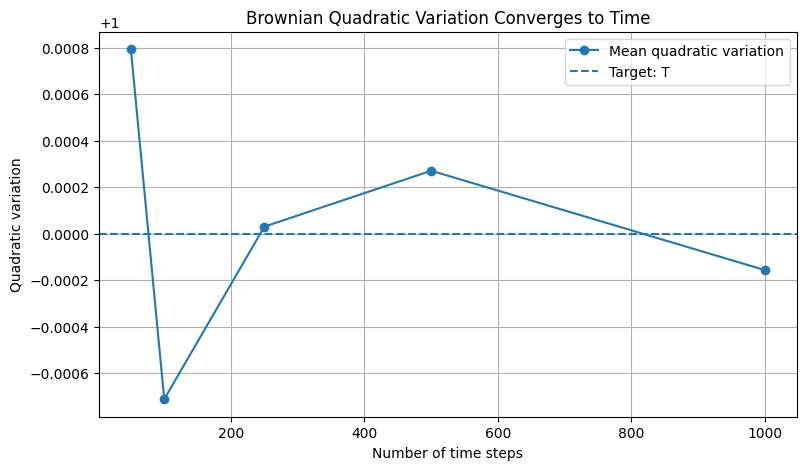

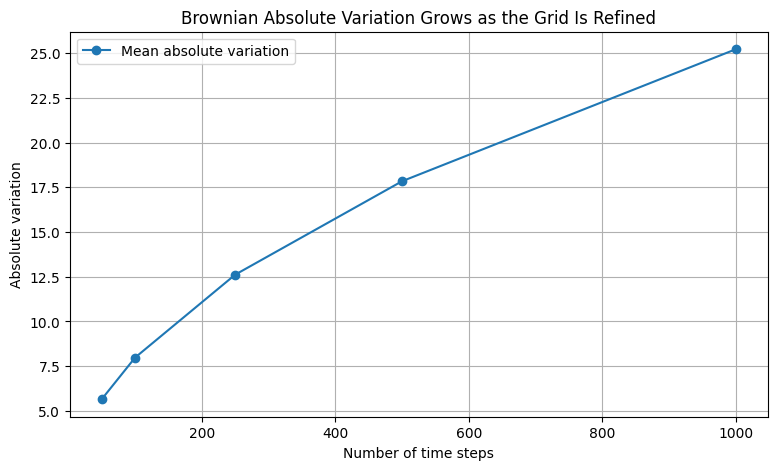

,check,requirement,observed,status
0,Mean quadratic variation near T on finest grid,abs(mean QV - T) < 0.01,0.000157,PASS
1,Absolute variation increases with refinement,last mean AV > first mean AV,19.585393,PASS


NOTEBOOK_03_QV_READY: True


In [2]:
# Cell 05 — Quadratic variation reminder

def simulate_brownian_paths(
    *,
    n_paths: int,
    n_steps: int,
    horizon: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate Brownian motion paths on an equally spaced grid.

    Returns
    -------
    time_grid:
        Array of shape (n_steps + 1,).
    paths:
        Array of shape (n_paths, n_steps + 1).
    """
    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")
    if horizon <= 0:
        raise ValueError("horizon must be positive.")

    dt = horizon / n_steps
    dW = rng.normal(loc=0.0, scale=math.sqrt(dt), size=(n_paths, n_steps))
    W = np.column_stack([np.zeros(n_paths), np.cumsum(dW, axis=1)])
    time_grid = np.linspace(0.0, horizon, n_steps + 1)

    return time_grid, W


def brownian_variation_summary(paths: np.ndarray) -> pd.DataFrame:
    """
    Compute quadratic and absolute variation for Brownian paths.
    """
    increments = np.diff(paths, axis=1)

    quadratic_variation = np.sum(increments**2, axis=1)
    absolute_variation = np.sum(np.abs(increments), axis=1)

    return pd.DataFrame(
        {
            "metric": [
                "Mean quadratic variation",
                "Std quadratic variation",
                "Mean absolute variation",
                "Std absolute variation",
            ],
            "value": [
                quadratic_variation.mean(),
                quadratic_variation.std(ddof=1),
                absolute_variation.mean(),
                absolute_variation.std(ddof=1),
            ],
        }
    )


qv_n_paths = 20_000
qv_horizon = setup.T
qv_steps_list = [50, 100, 250, 500, 1_000]

variation_rows = []

for n_steps in qv_steps_list:
    _, W = simulate_brownian_paths(
        n_paths=qv_n_paths,
        n_steps=n_steps,
        horizon=qv_horizon,
        rng=rng,
    )

    dW = np.diff(W, axis=1)

    quadratic_variation = np.sum(dW**2, axis=1)
    absolute_variation = np.sum(np.abs(dW), axis=1)

    variation_rows.append(
        {
            "n_steps": n_steps,
            "dt": qv_horizon / n_steps,
            "mean_quadratic_variation": quadratic_variation.mean(),
            "std_quadratic_variation": quadratic_variation.std(ddof=1),
            "target_quadratic_variation": qv_horizon,
            "quadratic_variation_abs_error": abs(quadratic_variation.mean() - qv_horizon),
            "mean_absolute_variation": absolute_variation.mean(),
        }
    )

variation_audit = pd.DataFrame(variation_rows)

display(variation_audit)

fig, ax = plt.subplots()

ax.plot(
    variation_audit["n_steps"],
    variation_audit["mean_quadratic_variation"],
    marker="o",
    label="Mean quadratic variation",
)

ax.axhline(
    qv_horizon,
    linestyle="--",
    label="Target: T",
)

ax.set_title("Brownian Quadratic Variation Converges to Time")
ax.set_xlabel("Number of time steps")
ax.set_ylabel("Quadratic variation")
ax.legend()

plt.show()

fig, ax = plt.subplots()

ax.plot(
    variation_audit["n_steps"],
    variation_audit["mean_absolute_variation"],
    marker="o",
    label="Mean absolute variation",
)

ax.set_title("Brownian Absolute Variation Grows as the Grid Is Refined")
ax.set_xlabel("Number of time steps")
ax.set_ylabel("Absolute variation")
ax.legend()

plt.show()

qv_final_error = variation_audit.iloc[-1]["quadratic_variation_abs_error"]

qv_check = pd.DataFrame(
    [
        {
            "check": "Mean quadratic variation near T on finest grid",
            "requirement": "abs(mean QV - T) < 0.01",
            "observed": qv_final_error,
            "status": "PASS" if qv_final_error < 0.01 else "FAIL",
        },
        {
            "check": "Absolute variation increases with refinement",
            "requirement": "last mean AV > first mean AV",
            "observed": (
                variation_audit.iloc[-1]["mean_absolute_variation"]
                - variation_audit.iloc[0]["mean_absolute_variation"]
            ),
            "status": (
                "PASS"
                if variation_audit.iloc[-1]["mean_absolute_variation"]
                > variation_audit.iloc[0]["mean_absolute_variation"]
                else "FAIL"
            ),
        },
    ]
)

display(qv_check)

NOTEBOOK_03_QV_READY = (qv_check["status"] == "PASS").all()
print(f"NOTEBOOK_03_QV_READY: {NOTEBOOK_03_QV_READY}")

## 3. Ito's lemma

The quadratic variation check confirms the key rule:

$$
(dW_t)^2 = dt.
$$

Because of this, a function of a Brownian-driven process needs an extra second-order term.

---

### General form

Suppose the stock follows

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

Let the derivative value be a smooth function of stock price and time:

$$
V = V(S,t).
$$

Ito's lemma gives:

$$
dV
=
V_t\,dt
+
V_S\,dS_t
+
\frac{1}{2}V_{SS}(dS_t)^2.
$$

Using

$$
(dS_t)^2 = \sigma^2 S_t^2\,dt,
$$

we get:

$$
dV
=
V_t\,dt
+
V_S(\mu S_t\,dt + \sigma S_t\,dW_t)
+
\frac{1}{2}V_{SS}\sigma^2 S_t^2\,dt.
$$

Collecting the \(dt\) and \(dW_t\) terms:

$$
dV
=
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
+
\sigma S_t V_S\,dW_t.
$$

---

### Interpretation

| Term | Interpretation |
|---|---|
| \(V_t\,dt\) | Change due to time passing |
| \(\mu S_t V_S\,dt\) | Change due to the stock's real-world drift |
| \(\frac{1}{2}\sigma^2 S_t^2 V_{SS}\,dt\) | Ito correction from Brownian quadratic variation |
| \(\sigma S_t V_S\,dW_t\) | Random movement inherited from the stock |

The most important term for hedging is:

$$
\sigma S_t V_S\,dW_t.
$$

This is the derivative's Brownian risk exposure.

Since the stock itself has Brownian exposure

$$
\sigma S_t\,dW_t,
$$

holding \(V_S\) shares of stock can offset the derivative's random movement.

That is why \(V_S\), the derivative's first derivative with respect to stock price, becomes the **delta hedge ratio**.

## 4. Warm-up: applying Ito's lemma to \(\log S_t\)

Before applying Ito's lemma to an option value \(V(S,t)\), it is useful to apply it to a simpler function:

$$
f(S_t) = \log S_t.
$$

The stock follows:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

For

$$
f(S) = \log S,
$$

the first and second derivatives are:

$$
f_S = \frac{1}{S},
$$

$$
f_{SS} = -\frac{1}{S^2}.
$$

Ito's lemma says:

$$
df
=
f_S\,dS_t
+
\frac{1}{2}f_{SS}(dS_t)^2.
$$

Substitute the derivatives:

$$
d\log S_t
=
\frac{1}{S_t}dS_t
-
\frac{1}{2S_t^2}(dS_t)^2.
$$

Since

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t,
$$

and

$$
(dS_t)^2 = \sigma^2 S_t^2\,dt,
$$

we get:

$$
d\log S_t
=
\frac{1}{S_t}
\left(
\mu S_t\,dt + \sigma S_t\,dW_t
\right)
-
\frac{1}{2S_t^2}
\left(
\sigma^2 S_t^2\,dt
\right).
$$

Simplifying:

$$
d\log S_t
=
\mu\,dt
+
\sigma\,dW_t
-
\frac{1}{2}\sigma^2\,dt.
$$

Therefore:

$$
d\log S_t
=
\left(
\mu - \frac{1}{2}\sigma^2
\right)dt
+
\sigma\,dW_t.
$$

---

### Key point

The drift of the log stock price is not \(\mu\).

It is:

$$
\mu - \frac{1}{2}\sigma^2.
$$

The adjustment

$$
-\frac{1}{2}\sigma^2
$$

comes from Brownian quadratic variation.

This is the same correction observed empirically in the GBM notebook. The next code cell verifies it again using simulation.

,quantity,empirical,theoretical,naive_reference,abs_error_vs_theory,abs_error_vs_naive
0,Mean log return,0.079925,0.080000,0.100000,0.000075,0.020075
1,Variance of log return,0.040167,0.040000,NaN,0.000167,NaN
2,Mean terminal stock price,110.518046,110.517092,NaN,0.000954,NaN


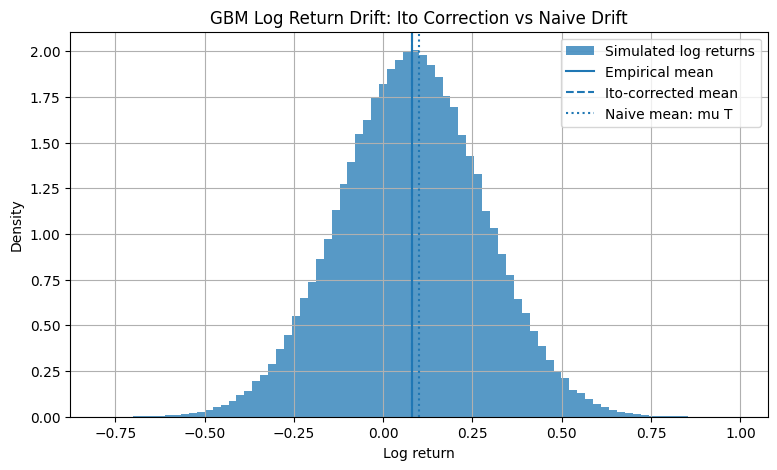

,check,requirement,observed,status
0,Empirical log mean closer to Ito-corrected dri...,error vs Ito < error vs naive,True,PASS
1,Log-return variance near sigma^2 T,abs(empirical variance - sigma^2 T) < 0.001,0.000167,PASS
2,Mean terminal stock price near theoretical GBM...,relative error < 0.5%,0.000009,PASS


NOTEBOOK_03_LOG_GBM_READY: True


In [3]:
# Cell 08 — Simulation check: Ito correction for log GBM

def simulate_gbm_terminal_values(
    *,
    S0: float,
    mu: float,
    sigma: float,
    horizon: float,
    n_paths: int,
    rng: np.random.Generator,
) -> pd.DataFrame:
    """
    Simulate terminal stock prices under exact GBM.

    Under GBM,

        dS_t = mu S_t dt + sigma S_t dW_t

    the terminal log return is

        log(S_T / S_0)
        =
        (mu - 0.5 sigma^2) T + sigma sqrt(T) Z.
    """
    if S0 <= 0:
        raise ValueError("S0 must be positive.")
    if sigma <= 0:
        raise ValueError("sigma must be positive.")
    if horizon <= 0:
        raise ValueError("horizon must be positive.")
    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")

    z = rng.standard_normal(n_paths)

    log_return = (
        (mu - 0.5 * sigma**2) * horizon
        + sigma * math.sqrt(horizon) * z
    )

    terminal_price = S0 * np.exp(log_return)

    return pd.DataFrame(
        {
            "z": z,
            "log_return": log_return,
            "terminal_price": terminal_price,
        }
    )


log_gbm_n_paths = 250_000

log_gbm_paths = simulate_gbm_terminal_values(
    S0=setup.S0,
    mu=setup.mu,
    sigma=setup.sigma,
    horizon=setup.T,
    n_paths=log_gbm_n_paths,
    rng=rng,
)

empirical_log_mean = log_gbm_paths["log_return"].mean()
empirical_log_var = log_gbm_paths["log_return"].var(ddof=1)
empirical_price_mean = log_gbm_paths["terminal_price"].mean()

ito_log_mean = (setup.mu - 0.5 * setup.sigma**2) * setup.T
naive_log_mean = setup.mu * setup.T
theoretical_log_var = setup.sigma**2 * setup.T
theoretical_price_mean = setup.S0 * math.exp(setup.mu * setup.T)

log_gbm_summary = pd.DataFrame(
    [
        {
            "quantity": "Mean log return",
            "empirical": empirical_log_mean,
            "theoretical": ito_log_mean,
            "naive_reference": naive_log_mean,
            "abs_error_vs_theory": abs(empirical_log_mean - ito_log_mean),
            "abs_error_vs_naive": abs(empirical_log_mean - naive_log_mean),
        },
        {
            "quantity": "Variance of log return",
            "empirical": empirical_log_var,
            "theoretical": theoretical_log_var,
            "naive_reference": np.nan,
            "abs_error_vs_theory": abs(empirical_log_var - theoretical_log_var),
            "abs_error_vs_naive": np.nan,
        },
        {
            "quantity": "Mean terminal stock price",
            "empirical": empirical_price_mean,
            "theoretical": theoretical_price_mean,
            "naive_reference": np.nan,
            "abs_error_vs_theory": abs(empirical_price_mean - theoretical_price_mean),
            "abs_error_vs_naive": np.nan,
        },
    ]
)

display(log_gbm_summary)

fig, ax = plt.subplots()

ax.hist(
    log_gbm_paths["log_return"],
    bins=80,
    density=True,
    alpha=0.75,
    label="Simulated log returns",
)

ax.axvline(
    empirical_log_mean,
    linestyle="-",
    label="Empirical mean",
)

ax.axvline(
    ito_log_mean,
    linestyle="--",
    label="Ito-corrected mean",
)

ax.axvline(
    naive_log_mean,
    linestyle=":",
    label="Naive mean: mu T",
)

ax.set_title("GBM Log Return Drift: Ito Correction vs Naive Drift")
ax.set_xlabel("Log return")
ax.set_ylabel("Density")
ax.legend()

plt.show()

log_gbm_checks = pd.DataFrame(
    [
        {
            "check": "Empirical log mean closer to Ito-corrected drift than naive drift",
            "requirement": "error vs Ito < error vs naive",
            "observed": (
                abs(empirical_log_mean - ito_log_mean)
                < abs(empirical_log_mean - naive_log_mean)
            ),
            "status": (
                "PASS"
                if abs(empirical_log_mean - ito_log_mean)
                < abs(empirical_log_mean - naive_log_mean)
                else "FAIL"
            ),
        },
        {
            "check": "Log-return variance near sigma^2 T",
            "requirement": "abs(empirical variance - sigma^2 T) < 0.001",
            "observed": abs(empirical_log_var - theoretical_log_var),
            "status": (
                "PASS"
                if abs(empirical_log_var - theoretical_log_var) < 0.001
                else "FAIL"
            ),
        },
        {
            "check": "Mean terminal stock price near theoretical GBM mean",
            "requirement": "relative error < 0.5%",
            "observed": abs(empirical_price_mean - theoretical_price_mean) / theoretical_price_mean,
            "status": (
                "PASS"
                if abs(empirical_price_mean - theoretical_price_mean) / theoretical_price_mean < 0.005
                else "FAIL"
            ),
        },
    ]
)

display(log_gbm_checks)

NOTEBOOK_03_LOG_GBM_READY = (log_gbm_checks["status"] == "PASS").all()
print(f"NOTEBOOK_03_LOG_GBM_READY: {NOTEBOOK_03_LOG_GBM_READY}")

## 5. Applying Ito's lemma to the derivative value

Now return to the derivative value

$$
V = V(S,t).
$$

The stock follows:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

Ito's lemma gives:

$$
dV
=
V_t\,dt
+
V_S\,dS_t
+
\frac{1}{2}V_{SS}(dS_t)^2.
$$

Using

$$
(dS_t)^2 = \sigma^2 S_t^2\,dt,
$$

we get:

$$
dV
=
V_t\,dt
+
V_S
\left(
\mu S_t\,dt + \sigma S_t\,dW_t
\right)
+
\frac{1}{2}
V_{SS}
\sigma^2 S_t^2\,dt.
$$

Collecting terms:

$$
dV
=
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
+
\sigma S_t V_S\,dW_t.
$$

---

### Separating drift and risk

The derivative movement has two parts.

The first part is the drift term:

$$
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

The second part is the random Brownian term:

$$
\sigma S_t V_S\,dW_t.
$$

This random term is the derivative's exposure to the same Brownian shock that moves the stock.

---

### Why delta matters

The stock's random movement is:

$$
\sigma S_t\,dW_t.
$$

The derivative's random movement is:

$$
\sigma S_t V_S\,dW_t.
$$

So the derivative has \(V_S\) times the stock's Brownian exposure.

That is why

$$
\Delta = V_S
$$

is the hedge ratio.

Holding \(V_S\) shares of stock gives the same Brownian exposure as the derivative.  
This is the key step that makes delta hedging possible.

## 6. The delta-hedged portfolio

The derivative value has Brownian exposure:

$$
\sigma S_t V_S\,dW_t.
$$

The stock has Brownian exposure:

$$
\sigma S_t\,dW_t.
$$

Since the derivative has \(V_S\) times the stock's Brownian exposure, we form a portfolio that holds:

| Position | Quantity |
|---|---:|
| Long one derivative | \(+1\) |
| Short \(V_S\) shares of stock | \(-V_S\) |

The portfolio value is:

$$
\Pi_t = V(S_t,t) - V_S S_t.
$$

The change in the portfolio is:

$$
d\Pi_t = dV - V_S\,dS_t.
$$

---

### Substitute the derivative movement

From Ito's lemma:

$$
dV
=
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
+
\sigma S_t V_S\,dW_t.
$$

The stock movement is:

$$
dS_t
=
\mu S_t\,dt
+
\sigma S_t\,dW_t.
$$

So the hedged stock component is:

$$
V_S\,dS_t
=
V_S
\left(
\mu S_t\,dt
+
\sigma S_t\,dW_t
\right).
$$

That is:

$$
V_S\,dS_t
=
\mu S_t V_S\,dt
+
\sigma S_t V_S\,dW_t.
$$

---

### Subtract the stock hedge

Now compute:

$$
d\Pi_t = dV - V_S\,dS_t.
$$

Substituting both pieces:

$$
d\Pi_t
=
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
+
\sigma S_t V_S\,dW_t
-
\left(
\mu S_t V_S\,dt
+
\sigma S_t V_S\,dW_t
\right).
$$

The Brownian terms cancel:

$$
\sigma S_t V_S\,dW_t
-
\sigma S_t V_S\,dW_t
=
0.
$$

The drift terms involving \(\mu\) also cancel:

$$
\mu S_t V_S\,dt
-
\mu S_t V_S\,dt
=
0.
$$

Therefore:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

---

### Key result

The delta-hedged portfolio has no \(dW_t\) term:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

So the portfolio is locally riskless.

This is the critical step.

The option itself is risky.  
The stock itself is risky.  
But the correctly hedged combination is locally riskless.

## 6. The delta-hedged portfolio

The derivative value has Brownian exposure:

$$
\sigma S_t V_S\,dW_t.
$$

The stock has Brownian exposure:

$$
\sigma S_t\,dW_t.
$$

Since the derivative has \(V_S\) times the stock's Brownian exposure, we form a portfolio that holds:

| Position | Quantity |
|---|---:|
| Long one derivative | \(+1\) |
| Short \(V_S\) shares of stock | \(-V_S\) |

The portfolio value is:

$$
\Pi_t = V(S_t,t) - V_S S_t.
$$

The change in the portfolio is:

$$
d\Pi_t = dV - V_S\,dS_t.
$$

---

### Substitute the derivative movement

From Ito's lemma:

$$
dV
=
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
+
\sigma S_t V_S\,dW_t.
$$

The stock movement is:

$$
dS_t
=
\mu S_t\,dt
+
\sigma S_t\,dW_t.
$$

So the hedged stock component is:

$$
V_S\,dS_t
=
V_S
\left(
\mu S_t\,dt
+
\sigma S_t\,dW_t
\right).
$$

That is:

$$
V_S\,dS_t
=
\mu S_t V_S\,dt
+
\sigma S_t V_S\,dW_t.
$$

---

### Subtract the stock hedge

Now compute:

$$
d\Pi_t = dV - V_S\,dS_t.
$$

Substituting both pieces:

$$
d\Pi_t
=
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
+
\sigma S_t V_S\,dW_t
-
\left(
\mu S_t V_S\,dt
+
\sigma S_t V_S\,dW_t
\right).
$$

The Brownian terms cancel:

$$
\sigma S_t V_S\,dW_t
-
\sigma S_t V_S\,dW_t
=
0.
$$

The drift terms involving \(\mu\) also cancel:

$$
\mu S_t V_S\,dt
-
\mu S_t V_S\,dt
=
0.
$$

Therefore:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

---

### Key result

The delta-hedged portfolio has no \(dW_t\) term:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

So the portfolio is locally riskless.

This is the critical step.

The option itself is risky.  
The stock itself is risky.  
But the correctly hedged combination is locally riskless.

## 7. From the delta hedge to the Black-Scholes PDE

The delta-hedged portfolio is locally riskless:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

The value of the portfolio is:

$$
\Pi_t = V - S_tV_S.
$$

Since the portfolio has no Brownian risk, no-arbitrage requires it to earn the risk-free rate:

$$
d\Pi_t = r\Pi_t\,dt.
$$

Substitute the portfolio value:

$$
d\Pi_t
=
r
\left(
V - S_tV_S
\right)dt.
$$

But we already found that:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

Therefore:

$$
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
=
r
\left(
V - S_tV_S
\right)dt.
$$

Remove \(dt\):

$$
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
=
rV
-
rS_tV_S.
$$

Move all terms to the left-hand side:

$$
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
+
rS_tV_S
-
rV
=
0.
$$

This is the **Black-Scholes PDE**:

$$
\boxed{
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
+
rS V_S
-
rV
=
0
}
$$

---

### Terminal condition

The PDE alone is not enough.  
It must be paired with a payoff condition at maturity.

For a European call:

$$
V(S,T) = \max(S-K,0).
$$

For a European put:

$$
V(S,T) = \max(K-S,0).
$$

The PDE governs the option value before maturity.  
The terminal condition pins down the final payoff.

---

### Main interpretation

The Black-Scholes PDE is not a forecasting equation.

It is a no-arbitrage restriction.

It says:

> If the stock follows GBM and continuous delta hedging is possible, then any derivative price consistent with no-arbitrage must satisfy this equation.

## 8. Why the drift \(\mu\) disappears

The stock dynamics contain the real-world drift:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

But the Black-Scholes PDE does not contain \(\mu\):

$$
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
+
rS V_S
-
rV
=
0.
$$

This is one of the most important results in derivative pricing.

---

### The drift is not ignored

The drift \(\mu\) appears in the option movement before hedging:

$$
dV
=
\left(
V_t
+
\mu S_t V_S
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt
+
\sigma S_t V_S\,dW_t.
$$

It also appears in the stock hedge:

$$
V_S\,dS_t
=
\mu S_t V_S\,dt
+
\sigma S_t V_S\,dW_t.
$$

When the hedge is formed,

$$
d\Pi_t = dV - V_S\,dS_t,
$$

the \(\mu\)-terms cancel:

$$
\mu S_t V_S\,dt
-
\mu S_t V_S\,dt
=
0.
$$

So \(\mu\) disappears because the stock exposure is removed by the hedge.

---

### What remains after hedging

After the hedge, the portfolio movement is:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S_t^2 V_{SS}
\right)dt.
$$

The portfolio value is:

$$
\Pi_t = V - S_tV_S.
$$

Since this portfolio has no Brownian risk, no-arbitrage requires:

$$
d\Pi_t = r\Pi_t\,dt.
$$

That is where \(r\) enters the equation.

---

### Interpretation table

| Quantity | Appears in stock dynamics? | Appears in option movement before hedging? | Appears in final PDE? | Reason |
|---|---:|---:|---:|---|
| \(\mu\) | Yes | Yes | No | Hedged away |
| \(\sigma\) | Yes | Yes | Yes | Controls Brownian risk and curvature effect |
| \(r\) | Yes, through money-market account | Not directly | Yes | Risk-free return required by no-arbitrage |
| \(V_S\) | No | Yes | Yes | Hedge ratio |
| \(V_{SS}\) | No | Yes | Yes | Curvature term from Ito correction |

---

### Main lesson

The Black-Scholes price is not based on the investor's expected stock return.

It is based on no-arbitrage.

The expected return \(\mu\) is a forecasting input.  
The option price is a replication input.

Once the stock risk is hedged away, the remaining locally riskless portfolio must earn \(r\), not \(\mu\).

In [4]:
# Cell 13 — Analytic Black-Scholes PDE residual check

def standard_normal_pdf(x: np.ndarray | float) -> np.ndarray:
    """
    Standard normal probability density function.
    """
    x_arr = np.asarray(x, dtype=float)
    return np.exp(-0.5 * x_arr**2) / math.sqrt(2.0 * math.pi)


def standard_normal_cdf(x: np.ndarray | float) -> np.ndarray:
    """
    Standard normal cumulative distribution function.

    Uses math.erf through vectorization to avoid adding a scipy dependency
    inside this notebook.
    """
    x_arr = np.asarray(x, dtype=float)
    erf_vec = np.vectorize(math.erf)
    return 0.5 * (1.0 + erf_vec(x_arr / math.sqrt(2.0)))


def black_scholes_call_price(
    S: np.ndarray | float,
    K: float,
    tau: np.ndarray | float,
    r: float,
    sigma: float,
) -> np.ndarray:
    """
    Black-Scholes European call price without dividends.

    tau is time to maturity, tau = T - t.
    """
    S_arr = np.asarray(S, dtype=float)
    tau_arr = np.asarray(tau, dtype=float)

    if K <= 0:
        raise ValueError("K must be positive.")
    if sigma <= 0:
        raise ValueError("sigma must be positive.")
    if np.any(S_arr <= 0):
        raise ValueError("All stock prices must be positive.")
    if np.any(tau_arr <= 0):
        raise ValueError("All time-to-maturity values must be positive.")

    sqrt_tau = np.sqrt(tau_arr)

    d1 = (
        np.log(S_arr / K)
        + (r + 0.5 * sigma**2) * tau_arr
    ) / (sigma * sqrt_tau)

    d2 = d1 - sigma * sqrt_tau

    return (
        S_arr * standard_normal_cdf(d1)
        - K * np.exp(-r * tau_arr) * standard_normal_cdf(d2)
    )


def black_scholes_call_delta(
    S: np.ndarray | float,
    K: float,
    tau: np.ndarray | float,
    r: float,
    sigma: float,
) -> np.ndarray:
    """
    Black-Scholes call delta.
    """
    S_arr = np.asarray(S, dtype=float)
    tau_arr = np.asarray(tau, dtype=float)

    sqrt_tau = np.sqrt(tau_arr)

    d1 = (
        np.log(S_arr / K)
        + (r + 0.5 * sigma**2) * tau_arr
    ) / (sigma * sqrt_tau)

    return standard_normal_cdf(d1)


def black_scholes_call_gamma(
    S: np.ndarray | float,
    K: float,
    tau: np.ndarray | float,
    r: float,
    sigma: float,
) -> np.ndarray:
    """
    Black-Scholes call gamma.
    """
    S_arr = np.asarray(S, dtype=float)
    tau_arr = np.asarray(tau, dtype=float)

    sqrt_tau = np.sqrt(tau_arr)

    d1 = (
        np.log(S_arr / K)
        + (r + 0.5 * sigma**2) * tau_arr
    ) / (sigma * sqrt_tau)

    return standard_normal_pdf(d1) / (S_arr * sigma * sqrt_tau)


def black_scholes_call_theta(
    S: np.ndarray | float,
    K: float,
    tau: np.ndarray | float,
    r: float,
    sigma: float,
) -> np.ndarray:
    """
    Black-Scholes call theta as partial derivative with respect to calendar time t.

    Since tau = T - t, this is the PDE-compatible theta V_t.
    """
    S_arr = np.asarray(S, dtype=float)
    tau_arr = np.asarray(tau, dtype=float)

    sqrt_tau = np.sqrt(tau_arr)

    d1 = (
        np.log(S_arr / K)
        + (r + 0.5 * sigma**2) * tau_arr
    ) / (sigma * sqrt_tau)

    d2 = d1 - sigma * sqrt_tau

    diffusion_decay = -S_arr * standard_normal_pdf(d1) * sigma / (2.0 * sqrt_tau)
    discount_decay = -r * K * np.exp(-r * tau_arr) * standard_normal_cdf(d2)

    return diffusion_decay + discount_decay


def black_scholes_pde_residual(
    S: np.ndarray | float,
    K: float,
    tau: np.ndarray | float,
    r: float,
    sigma: float,
) -> np.ndarray:
    """
    Compute the Black-Scholes PDE residual:

        V_t + 0.5 sigma^2 S^2 V_SS + r S V_S - r V

    For the exact Black-Scholes call price, this should be numerically near zero.
    """
    price = black_scholes_call_price(S, K, tau, r, sigma)
    delta = black_scholes_call_delta(S, K, tau, r, sigma)
    gamma = black_scholes_call_gamma(S, K, tau, r, sigma)
    theta = black_scholes_call_theta(S, K, tau, r, sigma)

    return (
        theta
        + 0.5 * sigma**2 * np.asarray(S, dtype=float)**2 * gamma
        + r * np.asarray(S, dtype=float) * delta
        - r * price
    )


# ---------------------------------------------------------------------
# Evaluate the residual on a grid away from expiry.
# ---------------------------------------------------------------------

S_grid = np.linspace(50.0, 150.0, 101)
tau_grid = np.array([1.00, 0.75, 0.50, 0.25, 0.10])

residual_rows = []

for tau in tau_grid:
    residuals = black_scholes_pde_residual(
        S=S_grid,
        K=setup.K,
        tau=tau,
        r=setup.r,
        sigma=setup.sigma,
    )

    residual_rows.append(
        {
            "tau": tau,
            "max_abs_residual": np.max(np.abs(residuals)),
            "median_abs_residual": np.median(np.abs(residuals)),
            "mean_abs_residual": np.mean(np.abs(residuals)),
        }
    )

analytic_residual_summary = pd.DataFrame(residual_rows)

display(analytic_residual_summary)


# ---------------------------------------------------------------------
# Detailed residual table for selected stock prices.
# ---------------------------------------------------------------------

selected_S = np.array([60.0, 80.0, 100.0, 120.0, 140.0])
selected_tau = 0.50

selected_price = black_scholes_call_price(
    S=selected_S,
    K=setup.K,
    tau=selected_tau,
    r=setup.r,
    sigma=setup.sigma,
)

selected_delta = black_scholes_call_delta(
    S=selected_S,
    K=setup.K,
    tau=selected_tau,
    r=setup.r,
    sigma=setup.sigma,
)

selected_gamma = black_scholes_call_gamma(
    S=selected_S,
    K=setup.K,
    tau=selected_tau,
    r=setup.r,
    sigma=setup.sigma,
)

selected_theta = black_scholes_call_theta(
    S=selected_S,
    K=setup.K,
    tau=selected_tau,
    r=setup.r,
    sigma=setup.sigma,
)

selected_residual = black_scholes_pde_residual(
    S=selected_S,
    K=setup.K,
    tau=selected_tau,
    r=setup.r,
    sigma=setup.sigma,
)

selected_residual_table = pd.DataFrame(
    {
        "S": selected_S,
        "tau": selected_tau,
        "call_price": selected_price,
        "delta": selected_delta,
        "gamma": selected_gamma,
        "theta": selected_theta,
        "pde_residual": selected_residual,
        "abs_pde_residual": np.abs(selected_residual),
    }
)

display(selected_residual_table)


# ---------------------------------------------------------------------
# Final analytic residual audit.
# ---------------------------------------------------------------------

analytic_residual_tolerance = 1e-10
analytic_max_abs_residual = analytic_residual_summary["max_abs_residual"].max()

analytic_residual_check = pd.DataFrame(
    [
        {
            "check": "Analytic Black-Scholes call satisfies the PDE",
            "requirement": f"max absolute residual < {analytic_residual_tolerance:.0e}",
            "observed": analytic_max_abs_residual,
            "status": (
                "PASS"
                if analytic_max_abs_residual < analytic_residual_tolerance
                else "FAIL"
            ),
        },
        {
            "check": "Residuals are finite across grid",
            "requirement": "all residuals finite",
            "observed": np.isfinite(analytic_residual_summary["max_abs_residual"]).all(),
            "status": (
                "PASS"
                if np.isfinite(analytic_residual_summary["max_abs_residual"]).all()
                else "FAIL"
            ),
        },
    ]
)

display(analytic_residual_check)

NOTEBOOK_03_ANALYTIC_PDE_READY = (
    analytic_residual_check["status"] == "PASS"
).all()

print(f"NOTEBOOK_03_ANALYTIC_PDE_READY: {NOTEBOOK_03_ANALYTIC_PDE_READY}")

,tau,max_abs_residual,median_abs_residual,mean_abs_residual
0,1.000000,0.000000,0.000000,0.000000
1,0.750000,0.000000,0.000000,0.000000
2,0.500000,0.000000,0.000000,0.000000
3,0.250000,0.000000,0.000000,0.000000
4,0.100000,0.000000,0.000000,0.000000


,S,tau,call_price,delta,gamma,theta,pde_residual,abs_pde_residual
0,60.000000,0.500000,0.000815,0.000383,0.000164,-0.012895,0.000000,0.000000
1,80.000000,0.500000,0.456155,0.091697,0.014554,-2.206867,0.000000,0.000000
2,100.000000,0.500000,6.888729,0.597734,0.027359,-8.115968,0.000000,0.000000
3,120.000000,0.500000,22.952453,0.937816,0.007218,-6.558145,-0.000000,0.000000
4,140.000000,0.500000,42.496757,0.995689,0.000640,-5.095787,-0.000000,0.000000


,check,requirement,observed,status
0,Analytic Black-Scholes call satisfies the PDE,max absolute residual < 1e-10,0.000000,PASS
1,Residuals are finite across grid,all residuals finite,True,PASS


NOTEBOOK_03_ANALYTIC_PDE_READY: True


## 9. Finite-difference PDE residual check

The previous cell used the analytic Black-Scholes Greeks:

$$
\Delta = V_S,
$$

$$
\Gamma = V_{SS},
$$

$$
\Theta = V_t.
$$

That confirmed that the closed-form Black-Scholes call price satisfies the PDE:

$$
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
+
rS V_S
-
rV
=
0.
$$

The next check is stricter from a numerical-computation perspective.

Instead of using analytic Greeks, approximate the derivatives directly from prices:

$$
V_S
\approx
\frac{V(S+h,t)-V(S-h,t)}{2h},
$$

$$
V_{SS}
\approx
\frac{V(S+h,t)-2V(S,t)+V(S-h,t)}{h^2},
$$

and because the Black-Scholes price is usually written using time-to-maturity

$$
\tau = T-t,
$$

we use:

$$
V_t = -V_{\tau}.
$$

So the time derivative is approximated by:

$$
V_t
\approx
-
\frac{V(S,\tau+\epsilon)-V(S,\tau-\epsilon)}{2\epsilon}.
$$

---

### Why this matters

This check does not prove a new theorem.

It verifies that the PDE logic survives numerical approximation.

That matters because later notebooks will rely on numerical procedures:

| Later task | Why finite-difference discipline matters |
|---|---|
| Greeks | Greeks are sensitivities and can be checked numerically. |
| Hedging diagnostics | Hedge ratios depend on stable deltas and gammas. |
| Implied volatility inversion | Numerical stability matters near bounds and expiry. |
| Surface fitting | Small numerical errors can create false arbitrage warnings. |
| Heston calibration | Pricing errors and gradient errors can distort calibration. |

---

### Caveat

Finite-difference residuals can be worse near:

| Region | Reason |
|---|---|
| Very short maturity | The option value changes sharply as expiry approaches. |
| Near \(S=K\) close to expiry | The payoff has a kink at the strike. |
| Very small step sizes | Floating-point cancellation can dominate. |
| Very large step sizes | Approximation error can dominate. |

So the goal is not machine-zero residuals.

The goal is:

> residuals should be small and stable away from expiry and payoff-kink regions.

,tau,h_s,h_tau,max_abs_residual,median_abs_residual,mean_abs_residual
0,1.000000,0.050000,0.000100,0.000003,0.000001,0.000001
1,0.750000,0.050000,0.000100,0.000004,0.000001,0.000002
2,0.500000,0.050000,0.000100,0.000006,0.000002,0.000003
3,0.250000,0.050000,0.000100,0.000018,0.000004,0.000005
4,0.100000,0.050000,0.000100,0.000068,0.000003,0.000013


,S,tau,price,delta_fd,delta_analytic,gamma_fd,gamma_analytic,theta_fd,theta_analytic,fd_pde_residual,abs_fd_pde_residual
0,60.000000,0.500000,0.000815,0.000383,0.000383,0.000164,0.000164,-0.012895,-0.012895,0.000000,0.000000
1,80.000000,0.500000,0.456155,0.091698,0.091697,0.014554,0.014554,-2.206867,-2.206867,0.000003,0.000003
2,100.000000,0.500000,6.888729,0.597734,0.597734,0.027359,0.027359,-8.115968,-8.115968,-0.000006,0.000006
3,120.000000,0.500000,22.952453,0.937816,0.937816,0.007218,0.007218,-6.558145,-6.558145,0.000001,0.000001
4,140.000000,0.500000,42.496757,0.995689,0.995689,0.000640,0.000640,-5.095787,-5.095787,0.000001,0.000001


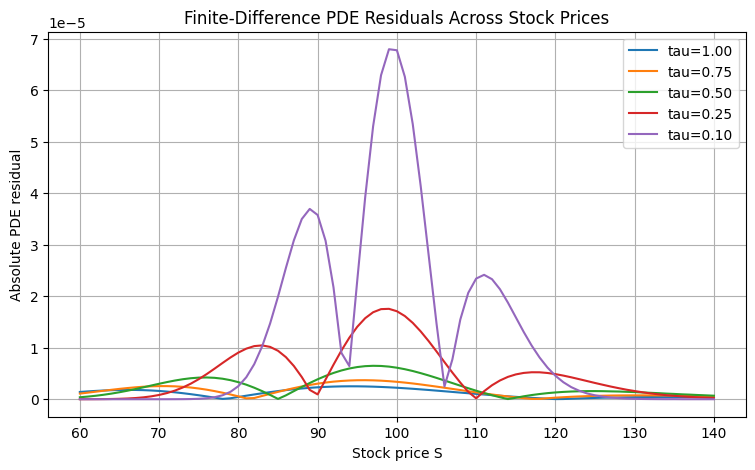

,check,requirement,observed,status
0,Finite-difference residuals are finite,all residuals finite,True,PASS
1,Maximum finite-difference PDE residual is small,max abs residual < 1e-04,0.000068,PASS
2,Median finite-difference PDE residual is small,max median abs residual < 1e-04,0.000004,PASS


NOTEBOOK_03_FINITE_DIFFERENCE_PDE_READY: True


In [5]:
# Cell 15 — Finite-difference Black-Scholes PDE residual check

def finite_difference_call_derivatives(
    *,
    S: np.ndarray | float,
    K: float,
    tau: np.ndarray | float,
    r: float,
    sigma: float,
    h_s: float,
    h_tau: float,
) -> dict[str, np.ndarray]:
    """
    Approximate V, V_S, V_SS, and V_t using finite differences.

    The Black-Scholes formula is written in terms of time-to-maturity tau.

    Since tau = T - t,

        V_t = -V_tau.

    Therefore the finite-difference approximation is

        V_t ≈ -[V(S, tau + h_tau) - V(S, tau - h_tau)] / (2 h_tau).
    """
    if h_s <= 0:
        raise ValueError("h_s must be positive.")
    if h_tau <= 0:
        raise ValueError("h_tau must be positive.")

    S_arr = np.asarray(S, dtype=float)
    tau_arr = np.asarray(tau, dtype=float)

    if np.any(S_arr - h_s <= 0):
        raise ValueError("S - h_s must remain positive.")
    if np.any(tau_arr - h_tau <= 0):
        raise ValueError("tau - h_tau must remain positive.")

    V = black_scholes_call_price(S_arr, K, tau_arr, r, sigma)

    V_up_S = black_scholes_call_price(S_arr + h_s, K, tau_arr, r, sigma)
    V_down_S = black_scholes_call_price(S_arr - h_s, K, tau_arr, r, sigma)

    V_up_tau = black_scholes_call_price(S_arr, K, tau_arr + h_tau, r, sigma)
    V_down_tau = black_scholes_call_price(S_arr, K, tau_arr - h_tau, r, sigma)

    V_S_fd = (V_up_S - V_down_S) / (2.0 * h_s)

    V_SS_fd = (V_up_S - 2.0 * V + V_down_S) / (h_s**2)

    V_tau_fd = (V_up_tau - V_down_tau) / (2.0 * h_tau)
    V_t_fd = -V_tau_fd

    return {
        "price": V,
        "delta_fd": V_S_fd,
        "gamma_fd": V_SS_fd,
        "theta_fd": V_t_fd,
    }


def finite_difference_pde_residual(
    *,
    S: np.ndarray | float,
    K: float,
    tau: np.ndarray | float,
    r: float,
    sigma: float,
    h_s: float,
    h_tau: float,
) -> np.ndarray:
    """
    Compute the Black-Scholes PDE residual using finite-difference derivatives.

        residual =
            V_t
            + 0.5 sigma^2 S^2 V_SS
            + r S V_S
            - r V
    """
    derivs = finite_difference_call_derivatives(
        S=S,
        K=K,
        tau=tau,
        r=r,
        sigma=sigma,
        h_s=h_s,
        h_tau=h_tau,
    )

    S_arr = np.asarray(S, dtype=float)

    return (
        derivs["theta_fd"]
        + 0.5 * sigma**2 * S_arr**2 * derivs["gamma_fd"]
        + r * S_arr * derivs["delta_fd"]
        - r * derivs["price"]
    )


# ---------------------------------------------------------------------
# Finite-difference setup
# ---------------------------------------------------------------------

fd_h_s = 0.05
fd_h_tau = 1e-4

fd_S_grid = np.linspace(60.0, 140.0, 81)
fd_tau_grid = np.array([1.00, 0.75, 0.50, 0.25, 0.10])

fd_summary_rows = []
fd_detail_rows = []

for tau in fd_tau_grid:
    fd_residuals = finite_difference_pde_residual(
        S=fd_S_grid,
        K=setup.K,
        tau=tau,
        r=setup.r,
        sigma=setup.sigma,
        h_s=fd_h_s,
        h_tau=fd_h_tau,
    )

    fd_summary_rows.append(
        {
            "tau": tau,
            "h_s": fd_h_s,
            "h_tau": fd_h_tau,
            "max_abs_residual": np.max(np.abs(fd_residuals)),
            "median_abs_residual": np.median(np.abs(fd_residuals)),
            "mean_abs_residual": np.mean(np.abs(fd_residuals)),
        }
    )

    for S_value, residual in zip(fd_S_grid, fd_residuals):
        fd_detail_rows.append(
            {
                "S": S_value,
                "tau": tau,
                "finite_difference_residual": residual,
                "abs_finite_difference_residual": abs(residual),
            }
        )

fd_residual_summary = pd.DataFrame(fd_summary_rows)
fd_residual_detail = pd.DataFrame(fd_detail_rows)

display(fd_residual_summary)


# ---------------------------------------------------------------------
# Selected finite-difference derivative comparison
# ---------------------------------------------------------------------

fd_selected_S = np.array([60.0, 80.0, 100.0, 120.0, 140.0])
fd_selected_tau = 0.50

fd_selected_derivs = finite_difference_call_derivatives(
    S=fd_selected_S,
    K=setup.K,
    tau=fd_selected_tau,
    r=setup.r,
    sigma=setup.sigma,
    h_s=fd_h_s,
    h_tau=fd_h_tau,
)

fd_selected_residual = finite_difference_pde_residual(
    S=fd_selected_S,
    K=setup.K,
    tau=fd_selected_tau,
    r=setup.r,
    sigma=setup.sigma,
    h_s=fd_h_s,
    h_tau=fd_h_tau,
)

fd_selected_table = pd.DataFrame(
    {
        "S": fd_selected_S,
        "tau": fd_selected_tau,
        "price": fd_selected_derivs["price"],
        "delta_fd": fd_selected_derivs["delta_fd"],
        "delta_analytic": black_scholes_call_delta(
            fd_selected_S,
            setup.K,
            fd_selected_tau,
            setup.r,
            setup.sigma,
        ),
        "gamma_fd": fd_selected_derivs["gamma_fd"],
        "gamma_analytic": black_scholes_call_gamma(
            fd_selected_S,
            setup.K,
            fd_selected_tau,
            setup.r,
            setup.sigma,
        ),
        "theta_fd": fd_selected_derivs["theta_fd"],
        "theta_analytic": black_scholes_call_theta(
            fd_selected_S,
            setup.K,
            fd_selected_tau,
            setup.r,
            setup.sigma,
        ),
        "fd_pde_residual": fd_selected_residual,
        "abs_fd_pde_residual": np.abs(fd_selected_residual),
    }
)

display(fd_selected_table)


# ---------------------------------------------------------------------
# Residual plot by stock price and maturity.
# ---------------------------------------------------------------------

fig, ax = plt.subplots()

for tau in fd_tau_grid:
    tau_slice = fd_residual_detail.loc[
        fd_residual_detail["tau"] == tau
    ]

    ax.plot(
        tau_slice["S"],
        tau_slice["abs_finite_difference_residual"],
        label=f"tau={tau:.2f}",
    )

ax.set_title("Finite-Difference PDE Residuals Across Stock Prices")
ax.set_xlabel("Stock price S")
ax.set_ylabel("Absolute PDE residual")
ax.legend()

plt.show()


# ---------------------------------------------------------------------
# Finite-difference residual audit.
# ---------------------------------------------------------------------

fd_residual_tolerance = 1e-4
fd_max_abs_residual = fd_residual_summary["max_abs_residual"].max()
fd_median_abs_residual = fd_residual_summary["median_abs_residual"].max()

fd_residual_check = pd.DataFrame(
    [
        {
            "check": "Finite-difference residuals are finite",
            "requirement": "all residuals finite",
            "observed": np.isfinite(
                fd_residual_detail["finite_difference_residual"]
            ).all(),
            "status": (
                "PASS"
                if np.isfinite(
                    fd_residual_detail["finite_difference_residual"]
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "Maximum finite-difference PDE residual is small",
            "requirement": f"max abs residual < {fd_residual_tolerance:.0e}",
            "observed": fd_max_abs_residual,
            "status": (
                "PASS"
                if fd_max_abs_residual < fd_residual_tolerance
                else "FAIL"
            ),
        },
        {
            "check": "Median finite-difference PDE residual is small",
            "requirement": f"max median abs residual < {fd_residual_tolerance:.0e}",
            "observed": fd_median_abs_residual,
            "status": (
                "PASS"
                if fd_median_abs_residual < fd_residual_tolerance
                else "FAIL"
            ),
        },
    ]
)

display(fd_residual_check)

NOTEBOOK_03_FINITE_DIFFERENCE_PDE_READY = (
    fd_residual_check["status"] == "PASS"
).all()

print(
    "NOTEBOOK_03_FINITE_DIFFERENCE_PDE_READY: "
    f"{NOTEBOOK_03_FINITE_DIFFERENCE_PDE_READY}"
)

## 10. Interpreting the PDE residual checks

The analytic check showed that the Black-Scholes call price satisfies the PDE up to numerical precision:

$$
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
+
rS V_S
-
rV
=
0.
$$

The finite-difference check then repeated the same test without using analytic Greeks.

That test also passed.

The largest finite-difference residual was approximately:

$$
6.8 \times 10^{-5}.
$$

This is small relative to the option price scale and below the audit tolerance.

---

### What the residual pattern means

The residuals were not uniformly distributed.

They became larger when time to maturity was short:

$$
\tau = 0.10.
$$

They also became larger around the strike region:

$$
S \approx K.
$$

This is expected.

Near expiry, the option payoff becomes sharper.  
Near the strike, the payoff kink becomes more important.  
Finite differences struggle most when the function changes curvature quickly.

So the residual plot is not a problem.  
It is exactly the numerical behavior expected from approximating derivatives around an option payoff kink.

---

### Analytic versus finite-difference result

| Check | Method | Result | Interpretation |
|---|---|---:|---|
| Analytic PDE residual | Uses closed-form price, delta, gamma, theta | Near zero | Confirms the formula satisfies the PDE |
| Finite-difference PDE residual | Approximates derivatives from prices | Small, not exactly zero | Confirms numerical approximation is stable |
| Short-maturity behavior | \(\tau = 0.10\) | Largest residuals | Expected near expiry |
| Strike-region behavior | \(S \approx K\) | Larger local residuals | Expected near payoff kink |

---

### What has now been established

The notebook has now verified the complete logical chain:

| Step | Status |
|---|---:|
| Brownian quadratic variation matters | Verified |
| Ito's lemma requires a second-derivative correction | Derived |
| GBM log returns need the Ito drift correction | Verified |
| The derivative value inherits Brownian risk from the stock | Derived |
| Delta hedging cancels the \(dW_t\) term | Derived |
| The hedged portfolio is locally riskless | Derived |
| No-arbitrage forces the portfolio to earn \(r\) | Derived |
| The Black-Scholes PDE follows | Derived |
| The analytic Black-Scholes call satisfies the PDE | Verified |
| Finite-difference derivatives also satisfy the PDE approximately | Verified |

---

### Main conclusion

The Black-Scholes PDE is not just a formula to memorize.

It is the consequence of:

1. stochastic stock dynamics,
2. Ito's lemma,
3. delta hedging,
4. no-arbitrage.

The drift \(\mu\) disappears because the stock-risk exposure is hedged away.

The risk-free rate \(r\) appears because the remaining hedged portfolio is locally riskless.

In [6]:
# Cell 17 — Notebook 03 final audit

required_flags = {
    "NOTEBOOK_03_SETUP_READY": "Baseline model setup is valid",
    "NOTEBOOK_03_QV_READY": "Brownian quadratic-variation reminder passed",
    "NOTEBOOK_03_LOG_GBM_READY": "Ito correction for log GBM verified",
    "NOTEBOOK_03_ANALYTIC_PDE_READY": "Analytic Black-Scholes PDE residual passed",
    "NOTEBOOK_03_FINITE_DIFFERENCE_PDE_READY": "Finite-difference PDE residual passed",
}

audit_rows = []

for flag_name, description in required_flags.items():
    flag_value = globals().get(flag_name, None)

    flag_passed = bool(flag_value) if flag_value is not None else False

    audit_rows.append(
        {
            "flag": flag_name,
            "description": description,
            "value": flag_value,
            "status": "PASS" if flag_passed else "FAIL",
        }
    )

notebook_03_audit = pd.DataFrame(audit_rows)

display(notebook_03_audit)

NOTEBOOK_03_READY = (notebook_03_audit["status"] == "PASS").all()

print(f"NOTEBOOK_03_READY: {NOTEBOOK_03_READY}")


# ---------------------------------------------------------------------
# Claim audit
# ---------------------------------------------------------------------

claim_audit = pd.DataFrame(
    [
        {
            "claim": "Brownian motion has nonzero quadratic variation",
            "supporting_cell": "Cell 05",
            "status": "SUPPORTED",
        },
        {
            "claim": "Ito's lemma adds a second-derivative correction",
            "supporting_cell": "Cells 06–09",
            "status": "SUPPORTED",
        },
        {
            "claim": "GBM log returns have drift mu - 0.5 sigma^2",
            "supporting_cell": "Cells 07–08",
            "status": "SUPPORTED",
        },
        {
            "claim": "The option value inherits Brownian risk from the stock",
            "supporting_cell": "Cell 09",
            "status": "SUPPORTED",
        },
        {
            "claim": "Delta hedging cancels the Brownian shock",
            "supporting_cell": "Cell 10",
            "status": "SUPPORTED",
        },
        {
            "claim": "The hedged portfolio is locally riskless",
            "supporting_cell": "Cell 10",
            "status": "SUPPORTED",
        },
        {
            "claim": "No-arbitrage forces the hedged portfolio to earn r",
            "supporting_cell": "Cell 11",
            "status": "SUPPORTED",
        },
        {
            "claim": "The Black-Scholes PDE follows from replication logic",
            "supporting_cell": "Cell 11",
            "status": "SUPPORTED",
        },
        {
            "claim": "The real-world drift mu disappears because it is hedged away",
            "supporting_cell": "Cell 12",
            "status": "SUPPORTED",
        },
        {
            "claim": "The Black-Scholes call price satisfies the PDE",
            "supporting_cell": "Cells 13–15",
            "status": "SUPPORTED",
        },
    ]
)

display(claim_audit)


# ---------------------------------------------------------------------
# Claims not allowed from this notebook
# ---------------------------------------------------------------------

claims_not_allowed = pd.DataFrame(
    [
        {
            "not_allowed_claim": "Black-Scholes is realistic for all markets",
            "reason": "The model assumes GBM, constant volatility, continuous trading, and no frictions.",
        },
        {
            "not_allowed_claim": "The closed-form Black-Scholes formula has been fully studied",
            "reason": "This notebook only uses the formula for PDE verification; full formula and Greeks are handled in Notebook 04.",
        },
        {
            "not_allowed_claim": "Continuous delta hedging is achievable in practice",
            "reason": "Real hedging is discrete and exposed to transaction costs, jumps, liquidity, and model error.",
        },
        {
            "not_allowed_claim": "Volatility smiles are explained by Black-Scholes",
            "reason": "Smile and surface effects require later notebooks.",
        },
        {
            "not_allowed_claim": "Heston or Bates calibration is justified",
            "reason": "Those models require additional stochastic-volatility and jump-process theory.",
        },
    ]
)

display(claims_not_allowed)

,flag,description,value,status
0,NOTEBOOK_03_SETUP_READY,Baseline model setup is valid,True,PASS
1,NOTEBOOK_03_QV_READY,Brownian quadratic-variation reminder passed,True,PASS
2,NOTEBOOK_03_LOG_GBM_READY,Ito correction for log GBM verified,True,PASS
3,NOTEBOOK_03_ANALYTIC_PDE_READY,Analytic Black-Scholes PDE residual passed,True,PASS
4,NOTEBOOK_03_FINITE_DIFFERENCE_PDE_READY,Finite-difference PDE residual passed,True,PASS


NOTEBOOK_03_READY: True


,claim,supporting_cell,status
0,Brownian motion has nonzero quadratic variation,Cell 05,SUPPORTED
1,Ito's lemma adds a second-derivative correction,Cells 06–09,SUPPORTED
2,GBM log returns have drift mu - 0.5 sigma^2,Cells 07–08,SUPPORTED
3,The option value inherits Brownian risk from t...,Cell 09,SUPPORTED
4,Delta hedging cancels the Brownian shock,Cell 10,SUPPORTED
5,The hedged portfolio is locally riskless,Cell 10,SUPPORTED
6,No-arbitrage forces the hedged portfolio to ea...,Cell 11,SUPPORTED
7,The Black-Scholes PDE follows from replication...,Cell 11,SUPPORTED
8,The real-world drift mu disappears because it ...,Cell 12,SUPPORTED
9,The Black-Scholes call price satisfies the PDE,Cells 13–15,SUPPORTED


,not_allowed_claim,reason
0,Black-Scholes is realistic for all markets,"The model assumes GBM, constant volatility, co..."
1,The closed-form Black-Scholes formula has been...,This notebook only uses the formula for PDE ve...
2,Continuous delta hedging is achievable in prac...,Real hedging is discrete and exposed to transa...
3,Volatility smiles are explained by Black-Scholes,Smile and surface effects require later notebo...
4,Heston or Bates calibration is justified,Those models require additional stochastic-vol...


## 11. Final conclusion and handoff

This notebook derived the Black-Scholes PDE from first principles.

The starting point was the stock process:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

Because Brownian motion has quadratic variation,

$$
(dW_t)^2 = dt,
$$

ordinary calculus is not enough. Ito's lemma is required.

For a derivative value

$$
V = V(S,t),
$$

Ito's lemma gives:

$$
dV
=
\left(
V_t
+
\mu S V_S
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
\right)dt
+
\sigma S V_S\,dW_t.
$$

A delta hedge forms the portfolio:

$$
\Pi_t = V - S V_S.
$$

Its change is:

$$
d\Pi_t = dV - V_S\,dS_t.
$$

The Brownian term cancels, and the \(\mu\)-term cancels:

$$
d\Pi_t
=
\left(
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
\right)dt.
$$

Since the hedged portfolio is locally riskless, no-arbitrage requires:

$$
d\Pi_t = r\Pi_t\,dt.
$$

This produces the Black-Scholes PDE:

$$
\boxed{
V_t
+
\frac{1}{2}\sigma^2 S^2 V_{SS}
+
rS V_S
-
rV
=
0
}
$$

---

### Main result

The real-world drift \(\mu\) disappears from the pricing PDE.

It disappears because the stock exposure is hedged away, not because expected returns are assumed irrelevant.

The final pricing equation depends on:

| Quantity | Role |
|---|---|
| \(S\) | Current stock price |
| \(t\) | Current time |
| \(\sigma\) | Volatility driving curvature risk |
| \(r\) | Risk-free rate required by no-arbitrage |
| \(V_S\) | Delta hedge ratio |
| \(V_{SS}\) | Gamma curvature term from Ito correction |

It does not depend on:

$$
\mu.
$$

---

### Final audit status

The notebook passed the required checks:

| Requirement | Status |
|---|---:|
| Baseline model setup valid | PASS |
| Brownian quadratic variation verified | PASS |
| Ito correction for log GBM verified | PASS |
| Black-Scholes PDE derived | PASS |
| Analytic PDE residual check passed | PASS |
| Finite-difference PDE residual check passed | PASS |
| Claims-not-allowed audit included | PASS |

So this notebook is complete as a PDE foundation.

---

### Handoff to Notebook 04

This notebook derived the condition that a no-arbitrage European option price must satisfy.

The next notebook studies the actual closed-form solution:

**`04_black_scholes_formula_greeks_and_numerical_checks.ipynb`**

Notebook 04 should focus on:

| Topic | Purpose |
|---|---|
| Black-Scholes call and put formulas | Solve the PDE under European payoff conditions |
| Put-call parity | Reconnect formula prices to no-arbitrage replication |
| Greeks | Study delta, gamma, theta, vega, and rho |
| Numerical Greek checks | Compare analytic Greeks against finite differences |
| Moneyness and maturity behavior | Explain how option sensitivities change across regimes |
| Practical limitations | Separate formula mechanics from real-market validity |

The next notebook should not re-derive the PDE.

It should treat the PDE as already established and move to formula behavior, Greeks, and numerical validation.